## 1. Import Libraries and Load Cleaned Data

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split,RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Lasso
from xgboost import XGBRegressor

from module_function import (cross_validate_model,plot_all_modelsRegression_predictions,
                             evaluate_models_Regression,feature_importance,plot_residuals,Hyperparameter_Tuning,plot_tuned_feature_importance)

import warnings
warnings.filterwarnings("ignore")

import pickle

In [19]:
df = pd.read_csv('dataset/communities_Crimecapita_CLEANING.csv')
df_x = df.drop(columns='ViolentCrimesPerPop')
df_y = df['ViolentCrimesPerPop']

In [20]:
X_train,X_test,y_train,y_test = train_test_split(df_x,df_y,test_size=0.2,random_state=42)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 363 samples
Test set: 91 samples


## 2. Feature Scaling

In [22]:
num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns
cat_cols = X_train.select_dtypes(include=['object', 'category']).columns

base_preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), num_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), cat_cols)
    ]
)

## 3.Pipeline All Models Regression

In [24]:
n = 15
regresi_pipelines = {
    'Linear Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', LinearRegression())
    ]),
    
    'Ridge Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', Ridge(alpha=1.0))
    ]),
    
    'Lasso Regression': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', Lasso(alpha=1.0, random_state=42, max_iter=10000))
    ]),
    
    'Random Forest Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', RandomForestRegressor(random_state=42))
    ]),
    
    'Gradient Boosting Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', GradientBoostingRegressor(random_state=42))
    ]),
    
    'XGBoost Regressor': Pipeline([
        ('preprocessing', base_preprocessor),
        ('feature_selection', SelectKBest(score_func=f_regression, k=n)),
        ('model', XGBRegressor(random_state=42, n_estimators=100, learning_rate=0.1))
    ])
}

## 4.Analysis Model Sebelum Cross-Validate

In [26]:
predictions_dict = {}
for model_name, pipeline in regresi_pipelines.items():
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    predictions_dict[model_name] = y_pred

df_report = evaluate_models_Regression( model_dict=predictions_dict, y_test=y_test)
df_report.sort_values(by='R2-Score', ascending=False)

Menguji model: Linear Regression
Menguji model: Ridge Regression
Menguji model: Lasso Regression
Menguji model: Random Forest Regressor
Menguji model: Gradient Boosting Regressor
Menguji model: XGBoost Regressor

Proses Training Selesai!


,Model,R2-Score,MAE,MSE,RMSE
1,Ridge Regression,0.2395,0.0657,0.0091,0.0952
0,Linear Regression,0.2387,0.0652,0.0091,0.0953
3,Random Forest Regressor,0.1050,0.0704,0.0107,0.1033
4,Gradient Boosting Regressor,0.0832,0.0705,0.0109,0.1046
2,Lasso Regression,-0.0492,0.0874,0.0125,0.1119
5,XGBoost Regressor,-0.1616,0.0773,0.0139,0.1177


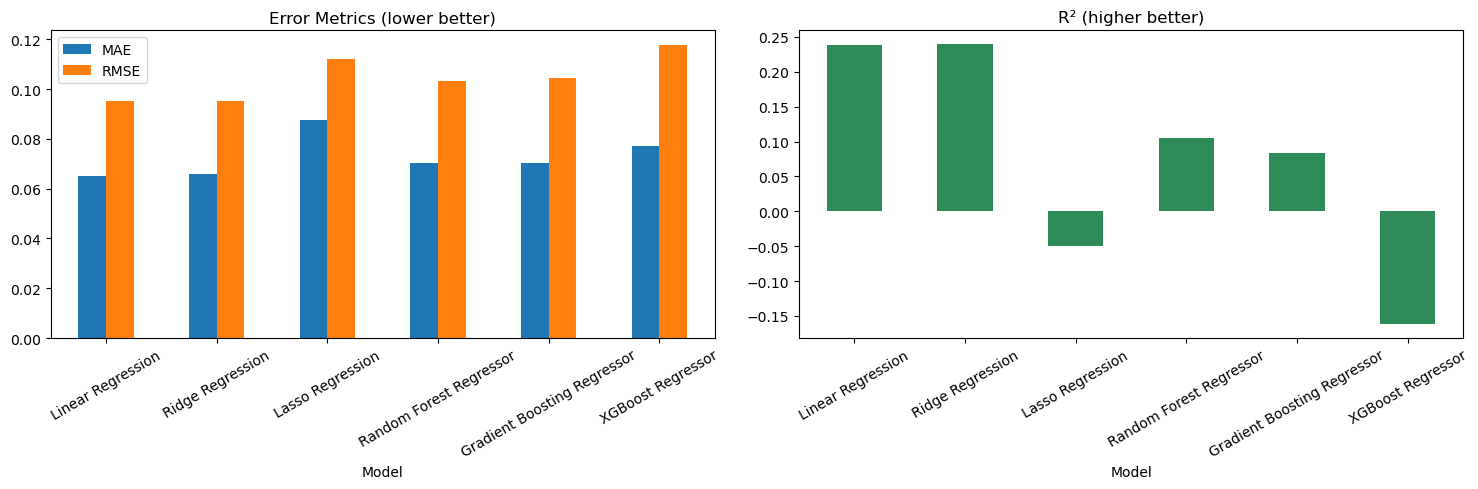

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_report.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)

df_report.set_index('Model')[['R2-Score']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 5.Analysis Model Sesudah Cross-Validate

In [29]:
df_hasil_perbandingan = cross_validate_model(models_dict=regresi_pipelines, X=X_train, y=y_train, cv_folds=5, mode='regression')
df_hasil_perbandingan.sort_values(by='R2-Score', ascending=False)

=== MENJALANKAN 5-FOLD CROSS VALIDATION (REGRESI) ===

Menguji model: Linear Regression
Menguji model: Ridge Regression
Menguji model: Lasso Regression
Menguji model: Random Forest Regressor
Menguji model: Gradient Boosting Regressor
Menguji model: XGBoost Regressor

Proses CV Selesai!


,Model,R2-Score,MAE,MSE,RMSE
1,Ridge Regression,0.394035,0.064841,0.008532,0.092368
0,Linear Regression,0.390452,0.065610,0.008555,0.092493
3,Random Forest Regressor,0.353403,0.066691,0.009061,0.095187
4,Gradient Boosting Regressor,0.269976,0.069708,0.010128,0.100638
5,XGBoost Regressor,0.218951,0.071408,0.010800,0.103925
2,Lasso Regression,-0.010936,0.086862,0.014020,0.118408


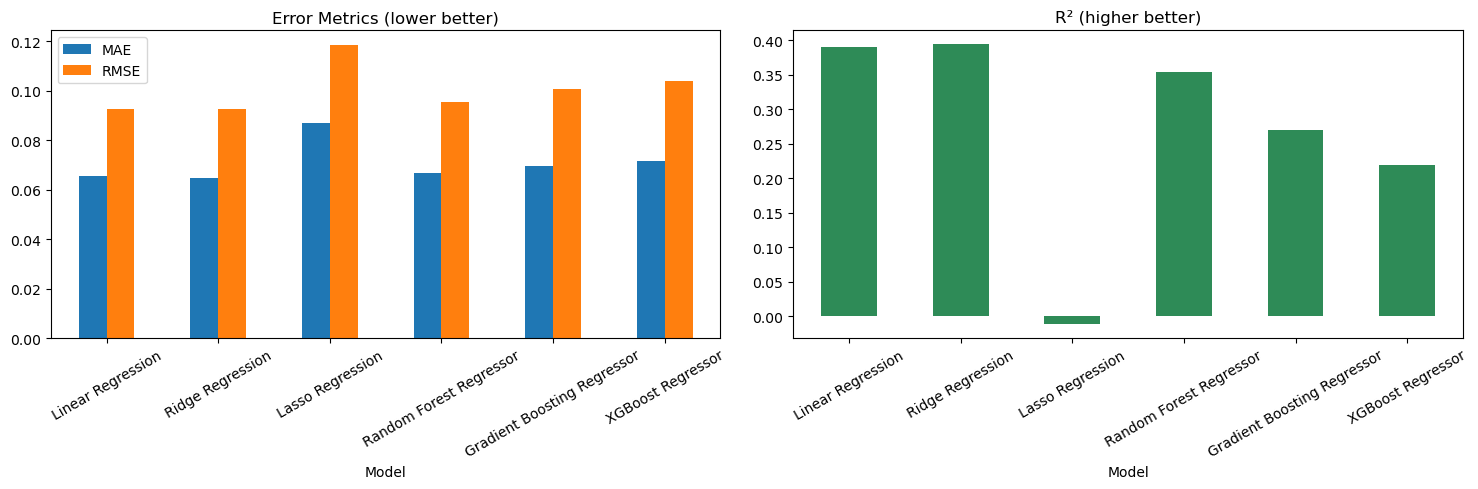

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
df_hasil_perbandingan.set_index('Model')[['MAE', 'RMSE']].plot(kind='bar', ax=axes[0])
axes[0].set_title('Error Metrics (lower better)')
axes[0].tick_params(axis='x', rotation=30)

df_hasil_perbandingan.set_index('Model')[['R2-Score']].plot(kind='bar', ax=axes[1], color='seagreen', legend=False)
axes[1].set_title('R² (higher better)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

## 6. Analysis Nilai Asli dan Nilai Prediksi

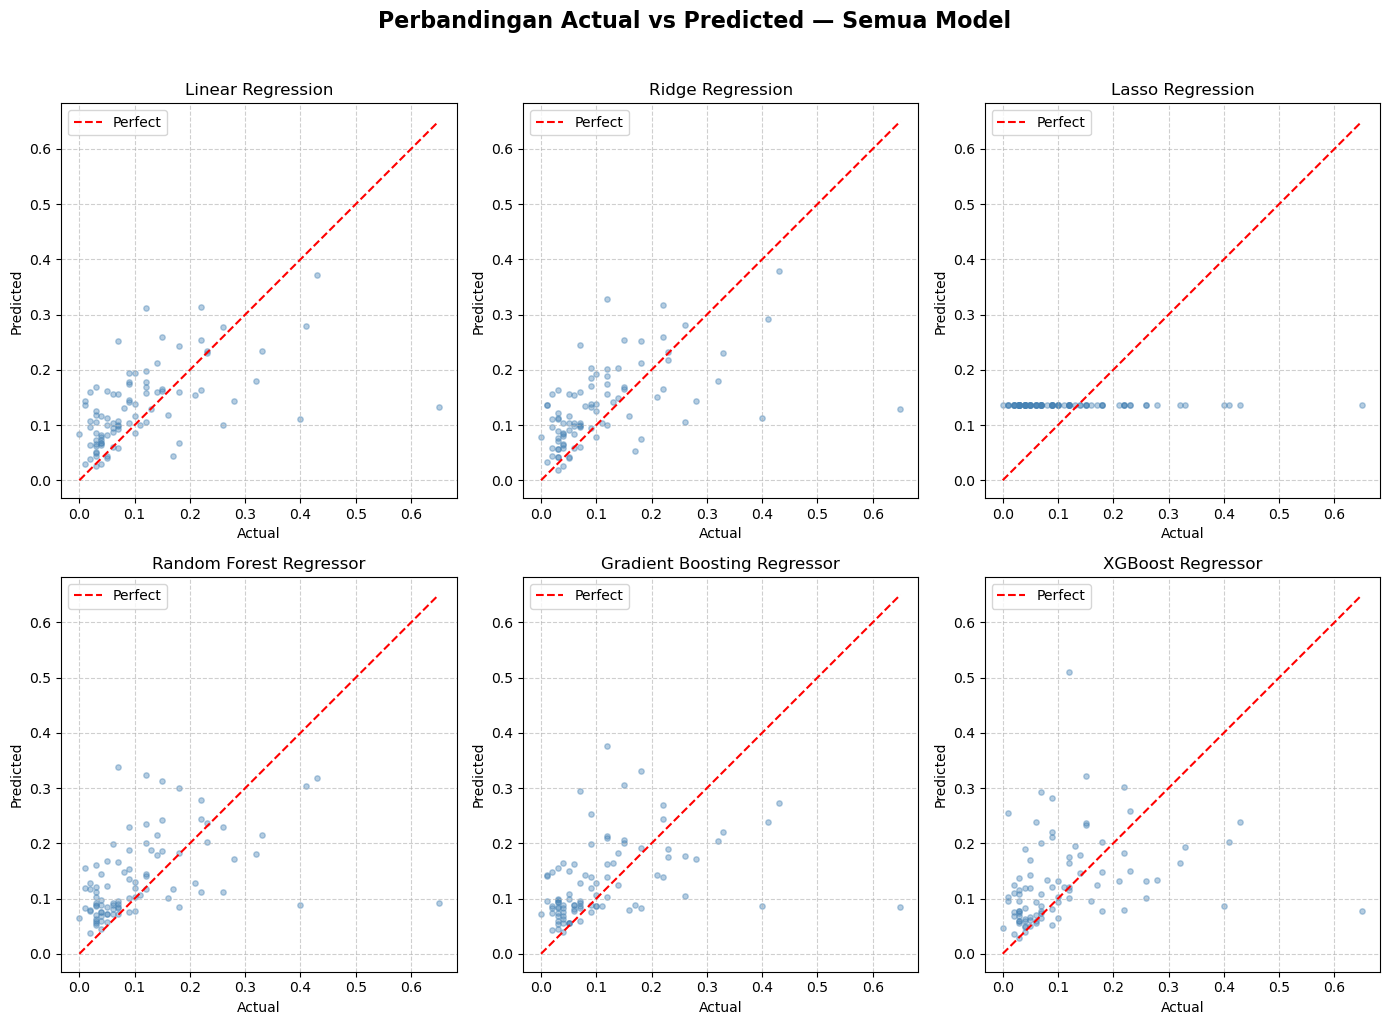

In [32]:
plot_all_modelsRegression_predictions( models_dict=regresi_pipelines, X_train=X_train, y_train=y_train, X_test=X_test, y_test=y_test,)

## 7. Importance Feature for Models

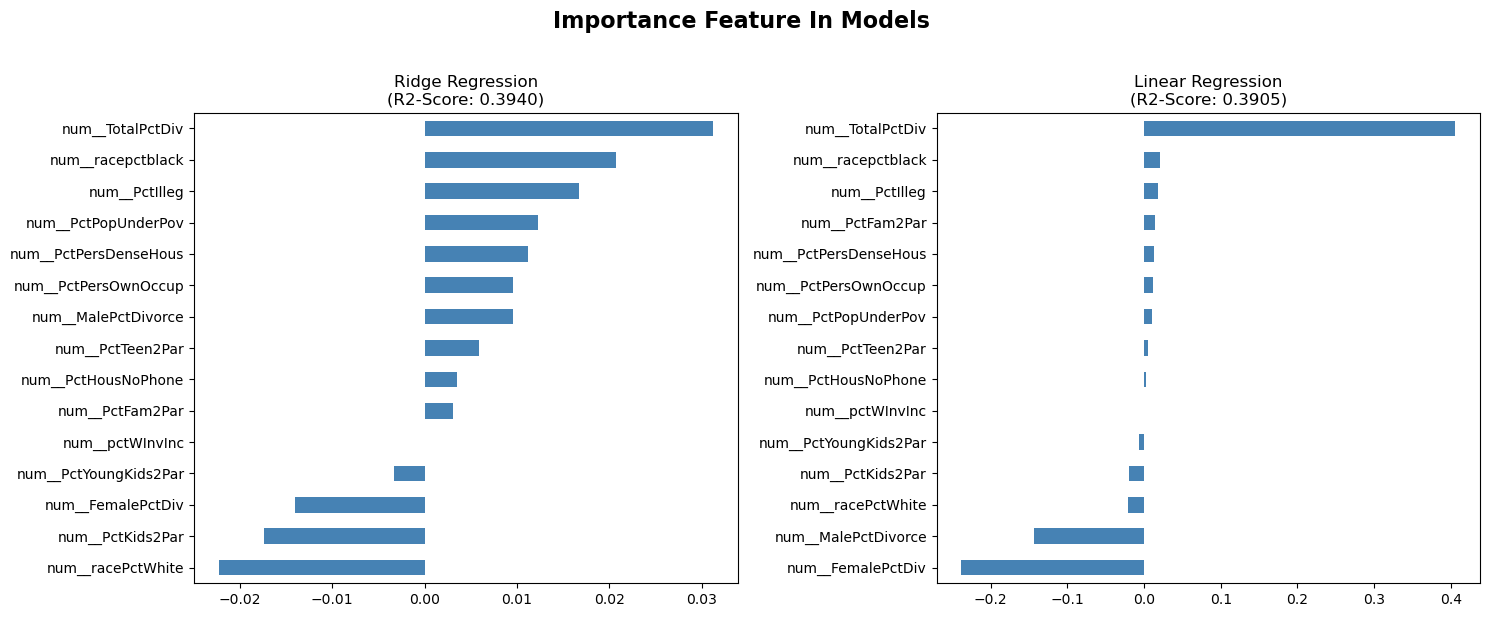

In [34]:
feature_importance(result_crossValidate=df_hasil_perbandingan,model_dict=regresi_pipelines)

## 8. Analysis Residuals — Best Model

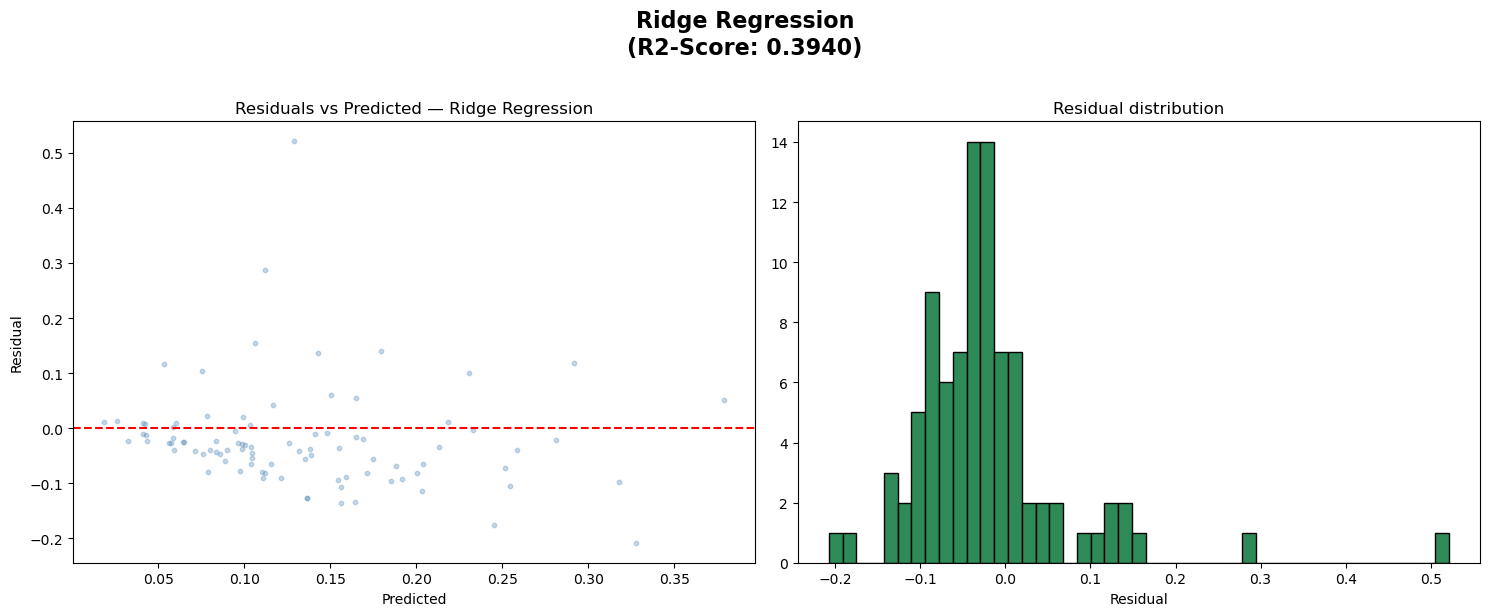

In [36]:
plot_residuals(result_crossValidate=df_hasil_perbandingan,model_dict=regresi_pipelines,x_test=X_test,y_test=y_test)

## 9. Hyperparameter Tuning — Best Performer

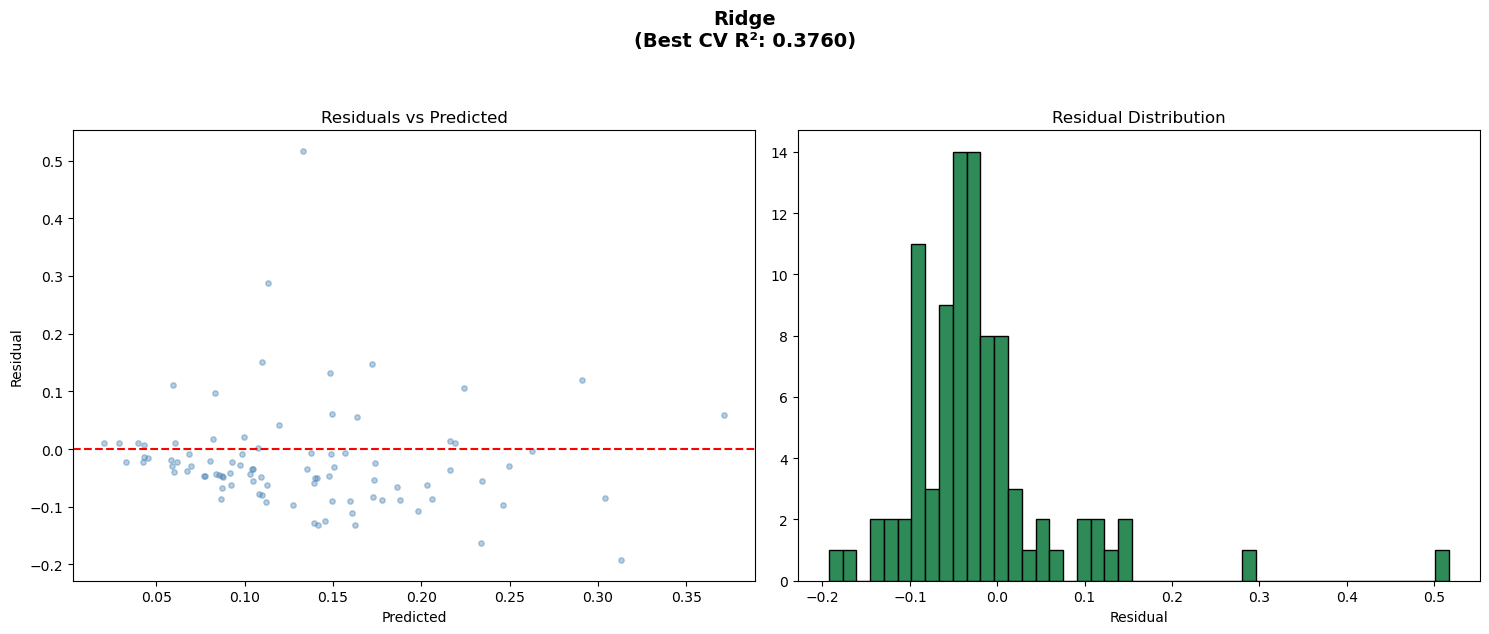

In [38]:
pipeline_model = regresi_pipelines['Ridge Regression']
params = {
    'model__alpha': np.logspace(-3, 3, 100),
    'model__solver': ['auto', 'svd', 'cholesky', 'lsqr', 'sag', 'saga']
}
best_model = Hyperparameter_Tuning(method='randomcv',pipeline_model=pipeline_model,cv=5,type_model='regression',
                                   param=params,x_train=X_train,y_train=y_train,x_test=X_test,y_test=y_test)

## 10. Tuned Model — Feature Importance

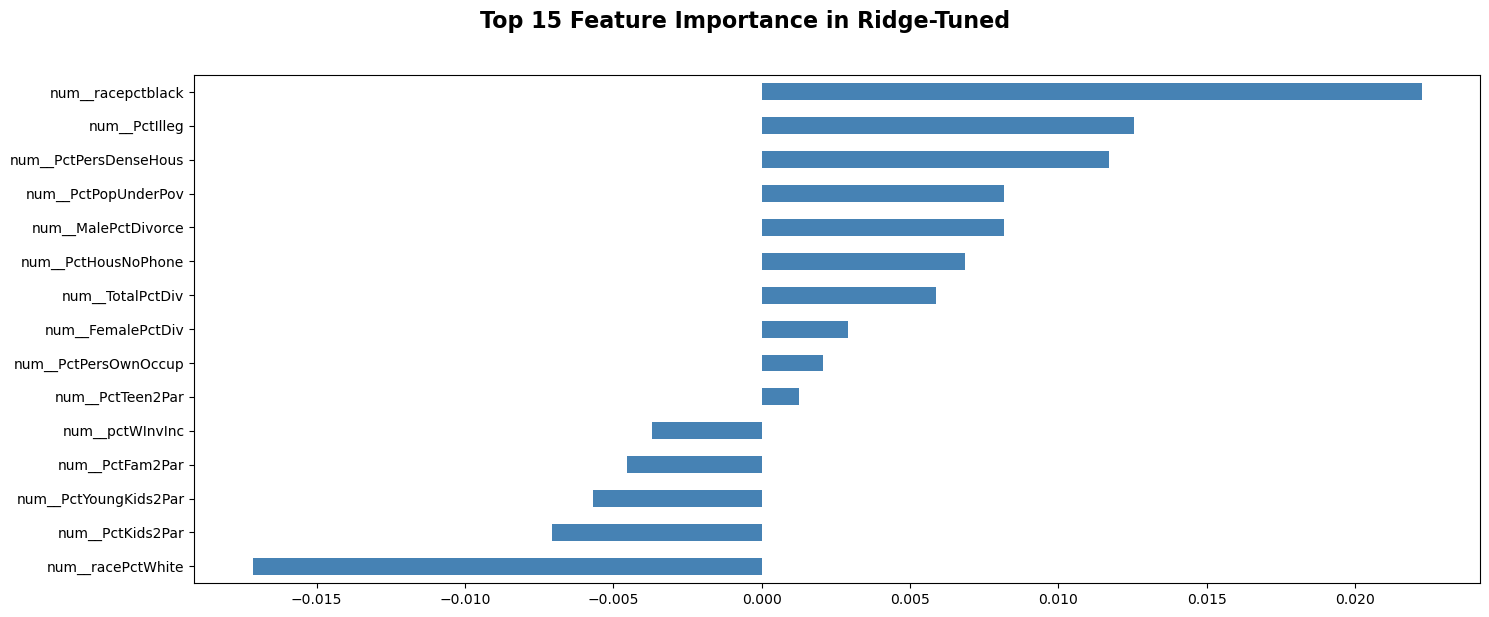

In [40]:
plot_tuned_feature_importance(tuned_model=best_model)

## 11. Simple Prediction

In [42]:
sample = X_test.iloc[:7].copy()
preds = best_model.predict(sample)

result = pd.DataFrame({'Predicted' : preds.round(2),
                       'Actual': y_test.iloc[:7].values.round(2)})
result['AbsError'] = (result['Predicted'] - result['Actual']).abs().round(2)
result

,Predicted,Actual,AbsError
0,0.06,0.07,0.01
1,0.09,0.04,0.05
2,0.04,0.05,0.01
3,0.22,0.23,0.01
4,0.14,0.01,0.13
5,0.17,0.09,0.08
6,0.15,0.02,0.13
